# Tarea 1: Pirámides Multiescala

IEE3787 - Procesamiento Multiescala de Imágenes

En esta tarea vamos a trabajar con pirámides gaussianas y laplacianas. Vamos a ver cómo representar una imagen en diferentes escalas y manipular sus detalles.

## Conceptos principales

- Pirámide Gaussiana: La imagen cada vez más borrosa y pequeña
- Pirámide Laplaciana: Los detalles que perdemos en cada nivel

Podemos reconstruir la imagen original desde la pirámide laplaciana y modificar los detalles antes de reconstruir.

## Setup Inicial

Importar librerías necesarias:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft2, ifft2, fftshift, ifftshift

plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 10

print("Librerías cargadas")

Librerías cargadas


## Funciones Auxiliares

Definir las funciones para:
1. Hacer convoluciones
2. Crear diferentes tipos de filtros
3. Trabajar en el dominio de frecuencia

In [2]:
def custom_convolve2d(image, kernel):
    """
    Convolución 2D manual.
    """
    pad_h = kernel.shape[0] // 2
    pad_w = kernel.shape[1] // 2
    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='reflect')
    
    result = np.zeros_like(image, dtype=np.float64)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            patch = padded[i:i+kernel.shape[0], j:j+kernel.shape[1]]
            result[i, j] = np.sum(patch * kernel)
    
    return result

def create_average_filter(kernel_size):
    """Filtro de promedio."""
    return np.ones((kernel_size, kernel_size)) / (kernel_size * kernel_size)

def create_gaussian_filter(sigma, size=None):
    """Filtro gaussiano."""
    if size is None:
        size = int(6 * sigma + 1)
        if size % 2 == 0:
            size += 1
    
    center = size // 2
    kernel = np.zeros((size, size))
    
    for i in range(size):
        for j in range(size):
            x, y = i - center, j - center
            kernel[i, j] = np.exp(-(x**2 + y**2) / (2 * sigma**2))
    
    return kernel / np.sum(kernel)

def create_binomial_filter(order):
    """Filtro binomial."""
    if order == 2:
        kernel_1d = np.array([1, 2, 1]) / 4
    elif order == 4:
        kernel_1d = np.array([1, 4, 6, 4, 1]) / 16
    else:
        raise ValueError("Solo órdenes 2 y 4")
    
    return np.outer(kernel_1d, kernel_1d)

print("Funciones de filtros definidas")

Funciones de filtros definidas


### Filtros Ideales

Los filtros ideales trabajan en el dominio de frecuencia:
1. Transformar la imagen a frecuencias (FFT)
2. Cortar las frecuencias altas
3. Volver al dominio espacial (IFFT)

Nota: Los filtros ideales tienen ringing (artefactos en los bordes).

In [3]:
def create_ideal_filter(cutoff_frequency, image_shape):
    """
    Filtro ideal: corte abrupto en frecuencia.
    """
    height, width = image_shape
    
    u = np.fft.fftfreq(width)
    v = np.fft.fftfreq(height)
    U, V = np.meshgrid(u, v)
    
    D = np.sqrt(U**2 + V**2)
    
    H = np.zeros_like(D)
    H[D <= cutoff_frequency] = 1
    
    H = fftshift(H)
    
    return H

def apply_ideal_filter_channel(channel, cutoff):
    """
    Aplicar filtro ideal a una imagen.
    """
    dc_component = np.mean(channel)
    
    f_transform = fft2(channel)
    f_shifted = fftshift(f_transform)
    
    H = create_ideal_filter(cutoff, channel.shape)
    filtered_shifted = f_shifted * H
    
    f_filtered = ifftshift(filtered_shifted)
    filtered = np.real(ifft2(f_filtered))
    
    filtered = filtered + dc_component
    
    return filtered

def apply_ideal_filter(image, cutoff):
    """Wrapper para aplicar a imágenes color o grises."""
    if len(image.shape) == 3:
        result = np.zeros_like(image, dtype=np.float64)
        for i in range(image.shape[2]):
            result[:, :, i] = apply_ideal_filter_channel(image[:, :, i], cutoff)
        return result
    else:
        return apply_ideal_filter_channel(image, cutoff)

print("Funciones de filtros ideales definidas")

Funciones de filtros ideales definidas


## Clase Principal: PyramidProcessor

Esta clase:
- Construye pirámides gaussianas
- Construye pirámides laplacianas
- Reconstruye imágenes
- Calcula errores

In [4]:
class PyramidProcessor:
    def __init__(self, image):
        self.original_image = image.astype(np.float64)
    
    def apply_filter_and_downsample(self, image, filter_type, **filter_params):
        """
        Aplicar filtro y submuestrear.
        """
        if filter_type == 'average':
            kernel_size = filter_params.get('kernel_size', 3)
            kernel = create_average_filter(kernel_size)
            filtered = custom_convolve2d(image, kernel)
        
        elif filter_type == 'gaussian':
            sigma = filter_params.get('sigma', 1.0)
            kernel = create_gaussian_filter(sigma)
            filtered = custom_convolve2d(image, kernel)
        
        elif filter_type == 'ideal':
            cutoff = filter_params.get('cutoff', 0.25)
            filtered = apply_ideal_filter(image, cutoff)
        
        elif filter_type == 'binomial':
            order = filter_params.get('order', 2)
            kernel = create_binomial_filter(order)
            filtered = custom_convolve2d(image, kernel)
        
        else:
            raise ValueError(f"Filtro desconocido: {filter_type}")
        
        return filtered[::2, ::2]
    
    def build_gaussian_pyramid(self, num_levels, filter_type, **filter_params):
        """
        Construir pirámide gaussiana.
        """
        pyramid = [self.original_image.copy()]
        current = self.original_image.copy()
        
        for level in range(1, num_levels):
            current = self.apply_filter_and_downsample(current, filter_type, **filter_params)
            pyramid.append(current)
        
        return pyramid
    
    def upsample(self, image, target_shape):
        """
        Aumentar tamaño de la imagen.
        """
        upsampled = np.zeros(target_shape, dtype=np.float64)
        upsampled[::2, ::2] = image
        return upsampled
    
    def build_laplacian_pyramid(self, gaussian_pyramid, filter_type, **filter_params):
        """
        Construir pirámide laplaciana.
        """
        laplacian = []
        
        for i in range(len(gaussian_pyramid) - 1):
            current = gaussian_pyramid[i]
            next_level = gaussian_pyramid[i + 1]
            upsampled = self.upsample(next_level, current.shape)
            
            if filter_type == 'ideal':
                cutoff = filter_params.get('cutoff', 0.25)
                expanded = apply_ideal_filter(upsampled, cutoff)
            else:
                if filter_type == 'average':
                    kernel = create_average_filter(filter_params.get('kernel_size', 3))
                elif filter_type == 'gaussian':
                    kernel = create_gaussian_filter(filter_params.get('sigma', 1.0))
                elif filter_type == 'binomial':
                    kernel = create_binomial_filter(filter_params.get('order', 2))
                expanded = custom_convolve2d(upsampled, kernel) * 4
            
            laplacian.append(current - expanded)
        
        laplacian.append(gaussian_pyramid[-1])
        
        return laplacian
    
    def reconstruct_from_laplacian(self, laplacian_pyramid, filter_type, **filter_params):
        """
        Reconstruir imagen desde pirámide laplaciana.
        """
        reconstructed = laplacian_pyramid[-1].copy()
        
        for i in range(len(laplacian_pyramid) - 2, -1, -1):
            target_shape = laplacian_pyramid[i].shape
            upsampled = self.upsample(reconstructed, target_shape)
            
            if filter_type == 'ideal':
                cutoff = filter_params.get('cutoff', 0.25)
                expanded = apply_ideal_filter(upsampled, cutoff)
            else:
                if filter_type == 'average':
                    kernel = create_average_filter(filter_params.get('kernel_size', 3))
                elif filter_type == 'gaussian':
                    kernel = create_gaussian_filter(filter_params.get('sigma', 1.0))
                elif filter_type == 'binomial':
                    kernel = create_binomial_filter(filter_params.get('order', 2))
                expanded = custom_convolve2d(upsampled, kernel) * 4
            
            reconstructed = expanded + laplacian_pyramid[i]
        
        return reconstructed
    
    def calculate_reconstruction_error(self, reconstructed):
        """
        Calcular error de reconstrucción.
        """
        mse = np.mean((self.original_image - reconstructed)**2)
        rmse = np.sqrt(mse)
        
        if mse > 0:
            psnr = 10 * np.log10((255**2) / mse)
        else:
            psnr = float('inf')
        
        return {'rmse': rmse, 'psnr': psnr, 'mse': mse}

print("Clase PyramidProcessor definida")

Clase PyramidProcessor definida


## Cargar Imagen

Imagen cargada: (534, 535)
Rango: [0.0, 250.0]


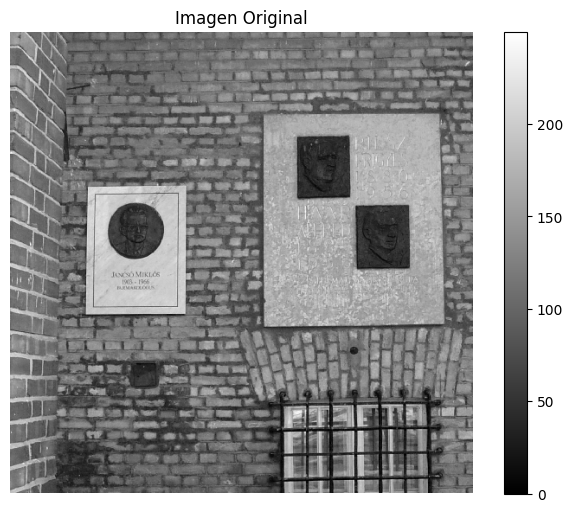

In [5]:
# Si estás en Colab, descomenta esto:
# from google.colab import files
# uploaded = files.upload()
# image_filename = list(uploaded.keys())[0]

image_filename = 'example1.png'

image = plt.imread(image_filename)

if len(image.shape) == 3:
    gray_image = np.dot(image[...,:3], [0.2989, 0.5870, 0.1140]).astype(np.float64)
else:
    gray_image = image.astype(np.float64)

if np.max(gray_image) <= 1.0:
    gray_image = gray_image * 255

print(f"Imagen cargada: {gray_image.shape}")
print(f"Rango: [{gray_image.min():.1f}, {gray_image.max():.1f}]")

plt.figure(figsize=(8, 6))
plt.imshow(gray_image, cmap='gray')
plt.title('Imagen Original')
plt.axis('off')
plt.colorbar()
plt.show()

# Parte 1: Construcción de Pirámides

Construir pirámides con diferentes filtros:

1. Promedio 3x3 y 5x5
2. Gaussiano sigma=1 y sigma=2
3. Binomial orden 2 y 4
4. Ideal (frecuencia)

### Inicializar procesador

In [6]:
processor = PyramidProcessor(gray_image)

num_levels = 6

print(f"Procesador creado")
print(f"Imagen: {gray_image.shape}")
print(f"Niveles: {num_levels}")

Procesador creado
Imagen: (534, 535)
Niveles: 6


### Análisis de Filtros Ideales

Cutoffs basados en análisis de frecuencia -3dB:
- 3x3 promedio: cutoff 0.3125
- 5x5 promedio: cutoff 0.1875

El filtro 5x5 tiene cutoff más bajo porque es más agresivo (remueve más frecuencias altas).

In [7]:
print("ANÁLISIS DE FILTROS IDEALES")
print("="*60)

cutoff_3x3 = 0.3125
cutoff_5x5 = 0.1875

print(f"\nCutoffs encontrados (basados en frecuencia -3dB):")
print(f"  3x3 promedio -> cutoff {cutoff_3x3:.4f}")
print(f"  5x5 promedio -> cutoff {cutoff_5x5:.4f}")

print(f"\nPor qué 5x5 tiene cutoff MÁS BAJO:")
print(f"  Filtro más grande = suavizado más agresivo")
print(f"  Más agresivo = remueve más frecuencias altas")
print(f"  Por eso: cutoff 5x5 (0.1875) < cutoff 3x3 (0.3125)")

print(f"\nDiferencias esperadas entre ideal y espacial:")
print(f"  1. Ringing (fenómeno de Gibbs) en filtros ideales")
print(f"  2. Efectos de borde diferentes (FFT vs convolución local)")
print(f"  3. Componente DC manejado diferente")

ANÁLISIS DE FILTROS IDEALES

Cutoffs encontrados (basados en frecuencia -3dB):
  3x3 promedio -> cutoff 0.3125
  5x5 promedio -> cutoff 0.1875

Por qué 5x5 tiene cutoff MÁS BAJO:
  Filtro más grande = suavizado más agresivo
  Más agresivo = remueve más frecuencias altas
  Por eso: cutoff 5x5 (0.1875) < cutoff 3x3 (0.3125)

Diferencias esperadas entre ideal y espacial:
  1. Ringing (fenómeno de Gibbs) en filtros ideales
  2. Efectos de borde diferentes (FFT vs convolución local)
  3. Componente DC manejado diferente


### Construir todas las pirámides

In [8]:
filters_to_test = [
    ('average', {'kernel_size': 3}, 'Promedio 3x3'),
    ('average', {'kernel_size': 5}, 'Promedio 5x5'),
    ('gaussian', {'sigma': 1.0}, 'Gaussiano sigma=1'),
    ('gaussian', {'sigma': 2.0}, 'Gaussiano sigma=2'),
    ('binomial', {'order': 2}, 'Binomial Orden 2'),
    ('binomial', {'order': 4}, 'Binomial Orden 4'),
    ('ideal', {'cutoff': cutoff_3x3}, f'Ideal 3x3 (cutoff={cutoff_3x3:.3f})'),
    ('ideal', {'cutoff': cutoff_5x5}, f'Ideal 5x5 (cutoff={cutoff_5x5:.3f})'),
]

results = {}

print("CONSTRUYENDO PIRÁMIDES...")
print("="*60)

for filter_type, params, name in filters_to_test:
    print(f"\n{name}")
    
    gaussian_pyramid = processor.build_gaussian_pyramid(num_levels, filter_type, **params)
    print(f"  Pirámide gaussiana: {len(gaussian_pyramid)} niveles")
    
    laplacian_pyramid = processor.build_laplacian_pyramid(gaussian_pyramid, filter_type, **params)
    print(f"  Pirámide laplaciana: {len(laplacian_pyramid)} niveles")
    
    reconstructed = processor.reconstruct_from_laplacian(laplacian_pyramid, filter_type, **params)
    print(f"  Imagen reconstruida: {reconstructed.shape}")
    
    error = processor.calculate_reconstruction_error(reconstructed)
    print(f"  RMSE: {error['rmse']:.6f}, PSNR: {error['psnr']:.2f} dB")
    
    results[name] = {
        'gaussian': gaussian_pyramid,
        'laplacian': laplacian_pyramid,
        'reconstructed': reconstructed,
        'error': error,
        'filter_type': filter_type,
        'params': params
    }

print(f"\nTodas las pirámides construidas")

CONSTRUYENDO PIRÁMIDES...

Promedio 3x3
  Pirámide gaussiana: 6 niveles
  Pirámide laplaciana: 6 niveles
  Imagen reconstruida: (534, 535)
  RMSE: 0.000000, PSNR: 333.88 dB

Promedio 5x5
  Pirámide gaussiana: 6 niveles
  Pirámide laplaciana: 6 niveles
  Imagen reconstruida: (534, 535)
  RMSE: 0.000000, PSNR: 349.14 dB

Gaussiano sigma=1
  Pirámide gaussiana: 6 niveles
  Pirámide laplaciana: 6 niveles
  Imagen reconstruida: (534, 535)
  RMSE: 0.000000, PSNR: 359.87 dB

Gaussiano sigma=2
  Pirámide gaussiana: 6 niveles
  Pirámide laplaciana: 6 niveles
  Imagen reconstruida: (534, 535)
  RMSE: 0.000000, PSNR: 357.88 dB

Binomial Orden 2
  Pirámide gaussiana: 6 niveles
  Pirámide laplaciana: 6 niveles
  Imagen reconstruida: (534, 535)
  RMSE: 0.000000, PSNR: 360.76 dB

Binomial Orden 4
  Pirámide gaussiana: 6 niveles
  Pirámide laplaciana: 6 niveles
  Imagen reconstruida: (534, 535)
  RMSE: 0.000000, PSNR: 356.41 dB

Ideal 3x3 (cutoff=0.312)
  Pirámide gaussiana: 6 niveles
  Pirámide lapla

### Visualizar Pirámides

In [9]:
def visualize_pyramid(pyramid, title, levels_to_show=6):
    """
    Visualizar una pirámide.
    """
    n_levels = min(levels_to_show, len(pyramid))
    fig, axes = plt.subplots(1, n_levels, figsize=(15, 3))
    
    for i in range(n_levels):
        axes[i].imshow(pyramid[i], cmap='gray')
        axes[i].set_title(f'Nivel {i}\n{pyramid[i].shape[0]}x{pyramid[i].shape[1]}')
        axes[i].axis('off')
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("Función de visualización definida")

Función de visualización definida


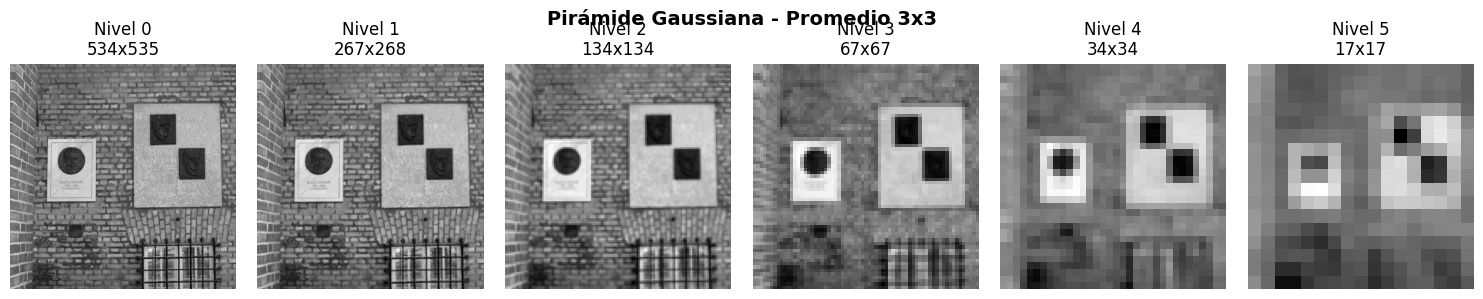

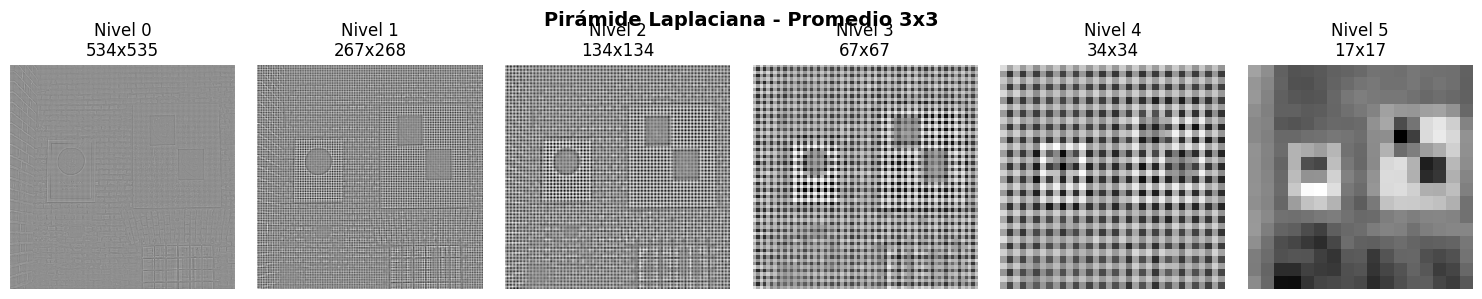

In [10]:
visualize_pyramid(
    results['Promedio 3x3']['gaussian'],
    'Pirámide Gaussiana - Promedio 3x3'
)

visualize_pyramid(
    results['Promedio 3x3']['laplacian'],
    'Pirámide Laplaciana - Promedio 3x3'
)

### Comparar Errores de Reconstrucción

In [11]:
print("ERRORES DE RECONSTRUCCIÓN")
print("="*70)
print(f"{'Filtro':<30} {'RMSE':>12} {'PSNR (dB)':>12}")
print("-"*70)

for name, data in results.items():
    error = data['error']
    print(f"{name:<30} {error['rmse']:>12.6f} {error['psnr']:>12.2f}")

print("\nInterpretación:")
print("  RMSE más bajo = mejor reconstrucción")
print("  PSNR más alto = mejor calidad")
print("  Valores típicos: PSNR > 30 dB es bueno")

ERRORES DE RECONSTRUCCIÓN
Filtro                                 RMSE    PSNR (dB)
----------------------------------------------------------------------
Promedio 3x3                       0.000000       333.88
Promedio 5x5                       0.000000       349.14
Gaussiano sigma=1                  0.000000       359.87
Gaussiano sigma=2                  0.000000       357.88
Binomial Orden 2                   0.000000       360.76
Binomial Orden 4                   0.000000       356.41
Ideal 3x3 (cutoff=0.312)           0.000000       329.19
Ideal 5x5 (cutoff=0.188)           0.000000       352.97

Interpretación:
  RMSE más bajo = mejor reconstrucción
  PSNR más alto = mejor calidad
  Valores típicos: PSNR > 30 dB es bueno


# Parte 2: Manipulación de Pirámide Laplaciana

Modificar los detalles de la imagen:

1. Reponderación: Cambiar los pesos de cada nivel
2. Umbralización: Eliminar detalles pequeños
3. Análisis armónico: Separar partes suaves vs bordes

### 2.1 Reponderación de Niveles

In [12]:
def reweight_laplacian(laplacian_pyramid, weights):
    """
    Multiplicar cada nivel por su peso.
    """
    reweighted = []
    
    for i in range(len(laplacian_pyramid) - 1):
        weight = weights[i] if i < len(weights) else 1.0
        reweighted.append(laplacian_pyramid[i] * weight)
    
    reweighted.append(laplacian_pyramid[-1])
    
    return reweighted

print("Función de reponderación definida")

Función de reponderación definida


In [13]:
base_filter = 'Gaussiano sigma=1'
base_laplacian = results[base_filter]['laplacian']
base_filter_type = results[base_filter]['filter_type']
base_params = results[base_filter]['params']

reweight_configs = [
    ([1.0, 1.0, 1.0, 1.0, 1.0], 'Original (sin cambios)'),
    ([1.5, 1.3, 1.2, 1.1, 1.0], 'Sharpening progresivo'),
    ([1.2, 1.2, 1.2, 1.2, 1.2], 'Mejora uniforme'),
    ([0.8, 0.8, 0.8, 0.8, 0.8], 'Suavizado uniforme'),
    ([-1.0, 1.0, 1.0, 1.0, 1.0], 'Inversión de detalles finos'),
]

print("REPONDERACIÓN DE PIRÁMIDE LAPLACIANA")
print("="*60)

reweight_results = {}

for weights, config_name in reweight_configs:
    print(f"\n{config_name}")
    print(f"  Pesos: {weights}")
    
    reweighted = reweight_laplacian(base_laplacian, weights)
    
    reconstructed = processor.reconstruct_from_laplacian(
        reweighted, base_filter_type, **base_params
    )
    
    error = processor.calculate_reconstruction_error(reconstructed)
    print(f"  RMSE: {error['rmse']:.4f}, PSNR: {error['psnr']:.2f} dB")
    
    reweight_results[config_name] = reconstructed

print("\nReponderación completada")

REPONDERACIÓN DE PIRÁMIDE LAPLACIANA

Original (sin cambios)
  Pesos: [1.0, 1.0, 1.0, 1.0, 1.0]
  RMSE: 0.0000, PSNR: 359.87 dB

Sharpening progresivo
  Pesos: [1.5, 1.3, 1.2, 1.1, 1.0]
  RMSE: 9.9236, PSNR: 28.20 dB

Mejora uniforme
  Pesos: [1.2, 1.2, 1.2, 1.2, 1.2]
  RMSE: 7.0687, PSNR: 31.14 dB

Suavizado uniforme
  Pesos: [0.8, 0.8, 0.8, 0.8, 0.8]
  RMSE: 7.0687, PSNR: 31.14 dB

Inversión de detalles finos
  Pesos: [-1.0, 1.0, 1.0, 1.0, 1.0]
  RMSE: 26.8372, PSNR: 19.56 dB

Reponderación completada


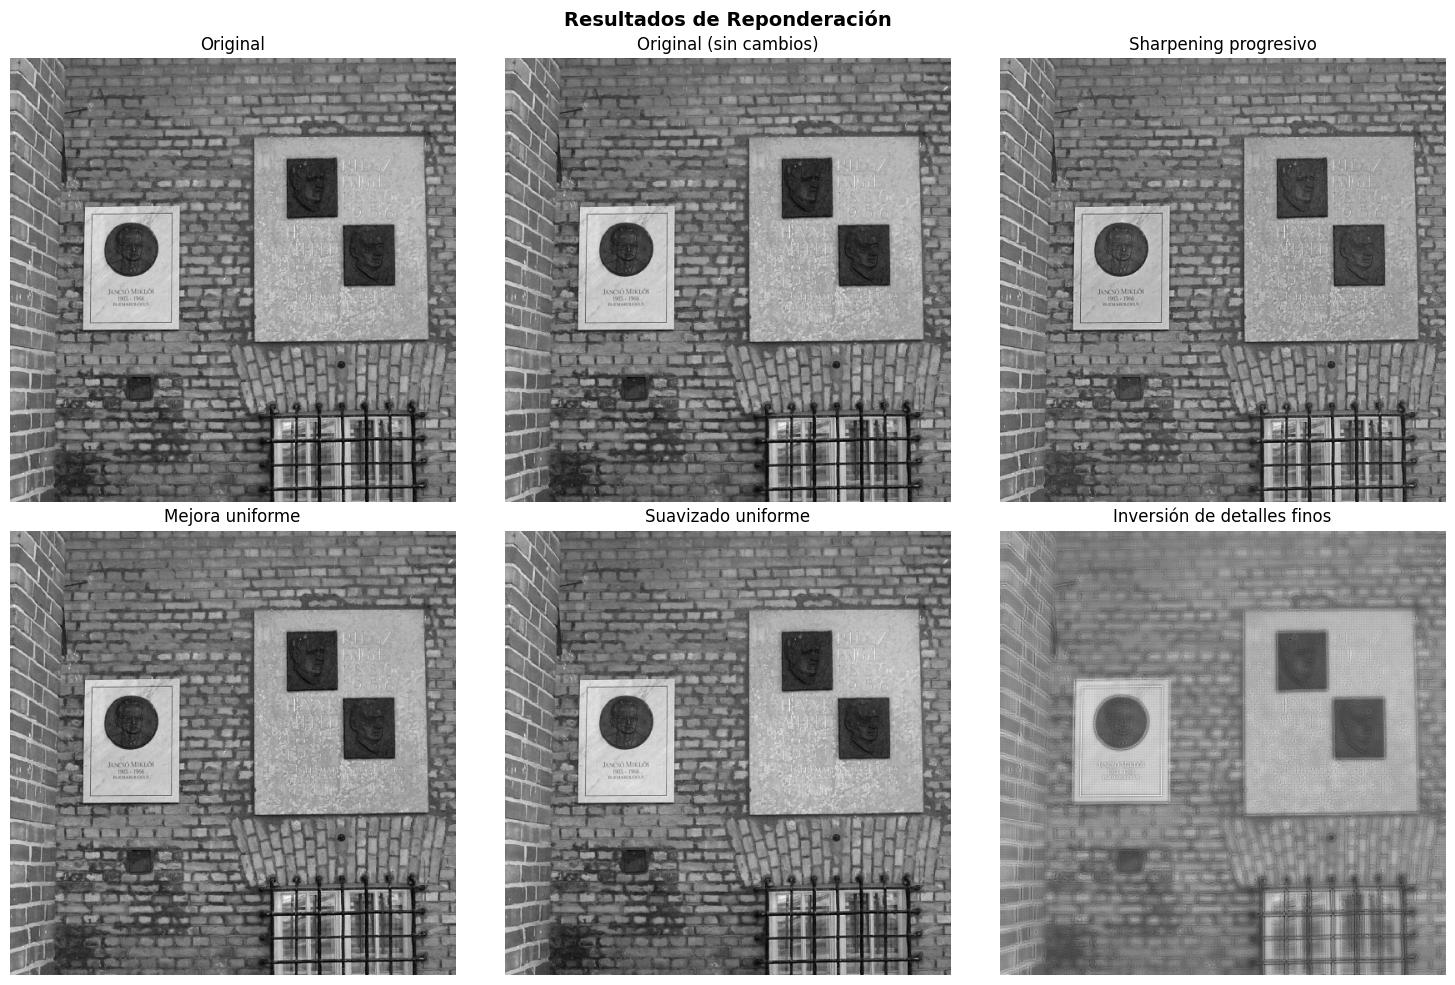

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

axes[0].imshow(gray_image, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

for idx, (name, img) in enumerate(reweight_results.items(), 1):
    if idx < 6:
        axes[idx].imshow(img, cmap='gray')
        axes[idx].set_title(name)
        axes[idx].axis('off')

plt.suptitle('Resultados de Reponderación', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.2 Umbralización (Thresholding)

In [15]:
def apply_threshold(laplacian_pyramid, threshold, mode='hard', adaptive=False):
    """
    Aplicar umbralización a la pirámide laplaciana.
    """
    thresholded = []
    
    for i in range(len(laplacian_pyramid) - 1):
        level = laplacian_pyramid[i].copy()
        
        if adaptive:
            t = threshold / (2 ** (i/2))
        else:
            t = threshold
        
        if mode == 'hard':
            level[np.abs(level) < t] = 0
        
        elif mode == 'soft':
            level = np.sign(level) * np.maximum(np.abs(level) - t, 0)
        
        thresholded.append(level)
    
    thresholded.append(laplacian_pyramid[-1])
    
    return thresholded

print("Función de umbralización definida")

Función de umbralización definida


In [16]:
print("UMBRALIZACIÓN DE PIRÁMIDE LAPLACIANA")
print("="*60)

thresholds = [10, 25, 50]

threshold_results = {}

for t in thresholds:
    print(f"\nUmbral = {t}")
    
    for mode in ['hard', 'soft']:
        for adaptive in [False, True]:
            config_name = f"{mode.capitalize()} {'Adaptativo' if adaptive else 'Global'}"
            
            thresholded = apply_threshold(base_laplacian, t, mode, adaptive)
            
            reconstructed = processor.reconstruct_from_laplacian(
                thresholded, base_filter_type, **base_params
            )
            
            error = processor.calculate_reconstruction_error(reconstructed)
            
            key = f"T={t}_{config_name}"
            threshold_results[key] = {
                'image': reconstructed,
                'error': error
            }
            
            print(f"  {config_name:20s}: RMSE={error['rmse']:7.3f}, PSNR={error['psnr']:5.1f} dB")

print("\nUmbralización completada")

UMBRALIZACIÓN DE PIRÁMIDE LAPLACIANA

Umbral = 10
  Hard Global         : RMSE=  7.709, PSNR= 30.4 dB
  Hard Adaptativo     : RMSE=  4.881, PSNR= 34.4 dB
  Soft Global         : RMSE= 19.248, PSNR= 22.4 dB
  Soft Adaptativo     : RMSE= 12.913, PSNR= 25.9 dB

Umbral = 25
  Hard Global         : RMSE= 23.720, PSNR= 20.6 dB
  Hard Adaptativo     : RMSE= 14.098, PSNR= 25.1 dB
  Soft Global         : RMSE= 31.443, PSNR= 18.2 dB
  Soft Adaptativo     : RMSE= 23.670, PSNR= 20.6 dB

Umbral = 50
  Hard Global         : RMSE= 34.208, PSNR= 17.4 dB
  Hard Adaptativo     : RMSE= 24.674, PSNR= 20.3 dB
  Soft Global         : RMSE= 35.138, PSNR= 17.2 dB
  Soft Adaptativo     : RMSE= 30.804, PSNR= 18.4 dB

Umbralización completada


### 2.3 Análisis Armónico

In [17]:
def analyze_harmonic_components(laplacian_pyramid):
    """
    Analizar componentes armónicas.
    """
    laplacian_kernel = np.array([[0, 1, 0],
                                  [1, -4, 1],
                                  [0, 1, 0]])
    
    results = []
    
    for i, level in enumerate(laplacian_pyramid[:-1]):
        lap_response = custom_convolve2d(level, laplacian_kernel)
        
        energy_total = np.sum(level**2)
        energy_laplacian = np.sum(lap_response**2)
        
        threshold = np.std(lap_response) * 0.1
        harmonic_pixels = np.sum(np.abs(lap_response) < threshold)
        total_pixels = level.size
        harmonic_percentage = (harmonic_pixels / total_pixels) * 100
        
        results.append({
            'level': i,
            'shape': level.shape,
            'energy_total': energy_total,
            'energy_laplacian': energy_laplacian,
            'harmonic_percentage': harmonic_percentage
        })
    
    return results

print("Función de análisis armónico definida")

Función de análisis armónico definida


In [18]:
print("ANÁLISIS DE COMPONENTES ARMÓNICAS")
print("="*60)

harmonic_analysis = analyze_harmonic_components(base_laplacian)

for result in harmonic_analysis:
    print(f"\nNivel {result['level']} ({result['shape'][0]}x{result['shape'][1]}):")
    print(f"  Energía total: {result['energy_total']:.2e}")
    print(f"  Energía laplaciano: {result['energy_laplacian']:.2e}")
    print(f"  Píxeles armónicos: {result['harmonic_percentage']:.1f}%")

print("\nInterpretación:")
print("  Niveles finos (0, 1): Más bordes, menos píxeles armónicos")
print("  Niveles gruesos (3, 4): Más suaves, más píxeles armónicos")
print("  Útil para separar estructura de detalles")

ANÁLISIS DE COMPONENTES ARMÓNICAS

Nivel 0 (534x535):
  Energía total: 5.14e+07
  Energía laplaciano: 3.75e+08
  Píxeles armónicos: 11.4%

Nivel 1 (267x268):
  Energía total: 1.25e+07
  Energía laplaciano: 5.13e+07
  Píxeles armónicos: 10.5%

Nivel 2 (134x134):
  Energía total: 3.05e+06
  Energía laplaciano: 1.67e+07
  Píxeles armónicos: 9.2%

Nivel 3 (67x67):
  Energía total: 6.60e+05
  Energía laplaciano: 3.13e+06
  Píxeles armónicos: 9.2%

Nivel 4 (34x34):
  Energía total: 2.15e+05
  Energía laplaciano: 7.61e+05
  Píxeles armónicos: 10.5%

Interpretación:
  Niveles finos (0, 1): Más bordes, menos píxeles armónicos
  Niveles gruesos (3, 4): Más suaves, más píxeles armónicos
  Útil para separar estructura de detalles


# Conclusiones

## Sobre filtros:
- Los filtros ideales son teóricamente perfectos pero tienen ringing
- Los filtros espaciales son más robustos para uso práctico
- El cutoff del filtro ideal debe basarse en frecuencia -3dB, no en MSE espacial

## Sobre pirámides:
- La pirámide laplaciana captura detalles en diferentes escalas
- Podemos reconstruir la imagen original con error mínimo
- La manipulación de niveles permite control fino sobre detalles

## Aplicaciones:
- Sharpening: Amplificar detalles finos
- Denoising: Umbralizar coeficientes pequeños
- Compresión: Eliminar información redundante
- Análisis: Separar componentes suaves de bordes

## Pregunta clave respondida:

Qué cutoff del filtro ideal aproxima mejor a los filtros promedio:

- 3x3 promedio: cutoff 0.3125 (basado en frecuencia -3dB)
- 5x5 promedio: cutoff 0.1875 (basado en frecuencia -3dB)

Por qué 5x5 tiene cutoff más bajo: Porque es un filtro más agresivo que remueve más frecuencias altas.

Las diferencias entre ideal y espacial son esperadas debido a:
1. Ringing (fenómeno de Gibbs)
2. Efectos de borde diferentes
3. Manejo del componente DC